# Parameterized Rotation Gates ($R_x, R_y, R_z$)

### Overview & Geometric Effects
* **Function:** Enables precise continuous rotation of a qubit state vector by an arbitrary angle around any of the three major coordinate axes ($X$, $Y$, or $Z$) on the Bloch sphere.
* **Circuit Representation:** Symbolically designated as $R_x(\theta)$, $R_y(\theta)$, and $R_z(\phi)$ blocks indicating the targeted axis and angle parameter in radians.
* **Arbitrary Superpositions:** Essential for steering state vectors to specific points between major axes (e.g., establishing a superposition state exactly halfway between $|0\rangle$ and the negative Y-axis by applying an $R_x(\pi/4)$ rotation to a $|0\rangle$ state).

---

### Mathematical Representations
Because rotation operators are generalized expressions to transition a state by any arbitrary value, they are represented using trigonometric and exponential matrices:

#### 1. The $R_x(\theta)$ Gate
Rotates the state vector around the X-axis by $\theta$ radians:
$$R_x(\theta) = \begin{bmatrix} \cos\left(\frac{\theta}{2}\right) & -i\sin\left(\frac{\theta}{2}\right) \\ -i\sin\left(\frac{\theta}{2}\right) & \cos\left(\frac{\theta}{2}\right) \end{bmatrix}$$

#### 2. The $R_y(\theta)$ Gate
Rotates the state vector around the Y-axis by $\theta$ radians (omitting imaginary parameters):
$$R_y(\theta) = \begin{bmatrix} \cos\left(\frac{\theta}{2}\right) & -\sin\left(\frac{\theta}{2}\right) \\ \sin\left(\frac{\theta}{2}\right) & \cos\left(\frac{\theta}{2}\right) \end{bmatrix}$$

$$\text{In both expressions, the variable } \theta \text{ determines how many radians to rotate around the x or y-axis on the Bloch sphere.}$$


#### 3. The $R_z(\phi)$ Gate
Rotates the state vector around the Z-axis by $\phi$ radians, exclusively modifying the relative phase:
$$R_z(\phi) = \begin{bmatrix} e^{-i\frac{\phi}{2}} & 0 \\ 0 & e^{i\frac{\phi}{2}} \end{bmatrix}$$

$$\text{
The variable $\phi$ is utilized here instead of $\theta$ to specify that the $R_z$ gate executes a rotation around the Z-axis, which uniquely alters the relative phase of the qubit.
}$$


---

### Relationships to Pauli Logic Gates (Rotations of $\pi$ Radians)
Geometrically, rotating a state vector by $\pi$ radians ($180^\circ$) around a primary axis flips the qubit identically to its corresponding Pauli gate. Mathematically, substituting $\pi$ into the parameterized equations reveals that they match the Pauli operations up to an unobservable global phase factor ($i$ or $-i$):

* **X-Axis:** An $R_x(\pi)$ rotation yields a matrix of zeros and negative $i$'s, factoring out to match the Pauli-X gate:
  $$R_x(\pi) = \begin{bmatrix} 0 & -i \\ -i & 0 \end{bmatrix} = -i\begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix} = -iX$$

* **Y-Axis:** An $R_y(\pi)$ rotation scales to the Pauli-Y gate:
  $$R_y(\pi) = \begin{bmatrix} 0 & -1 \\ 1 & 0 \end{bmatrix} = i\begin{bmatrix} 0 & -i \\ i & 0 \end{bmatrix} = iY$$

* **Z-Axis:** An $R_z(\pi)$ rotation maps back to the Pauli-Z gate:
  $$R_z(\pi) = \begin{bmatrix} -i & 0 \\ 0 & i \end{bmatrix} = -i\begin{bmatrix} 1 & 0 \\ 0 & -1 \end{bmatrix} = -iZ$$


In [20]:
from qiskit import *
from qiskit import transpile
from qiskit.visualization import plot_histogram, array_to_latex, plot_bloch_multivector
from qiskit_aer import Aer
from qiskit.quantum_info.states import statevector
from qiskit.transpiler import AnalysisPass
from math import pi
import matplotlib.pyplot as plt

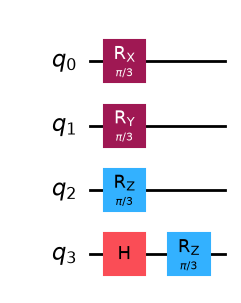

In [21]:
circuit = QuantumCircuit(4)
circuit.rx(pi/3, 0)
circuit.ry(pi/3, 1)
circuit.rz(pi/3, 2)

circuit.h(3)
circuit.rz(pi/3, 3)



circuit.draw(output='mpl')

In [22]:
simulator = Aer.get_backend('statevector_simulator')
compiled = transpile(circuit, simulator)
result = simulator.run(compiled).result()
statevector = result.get_statevector()
array_to_latex(statevector)

<IPython.core.display.Latex object>

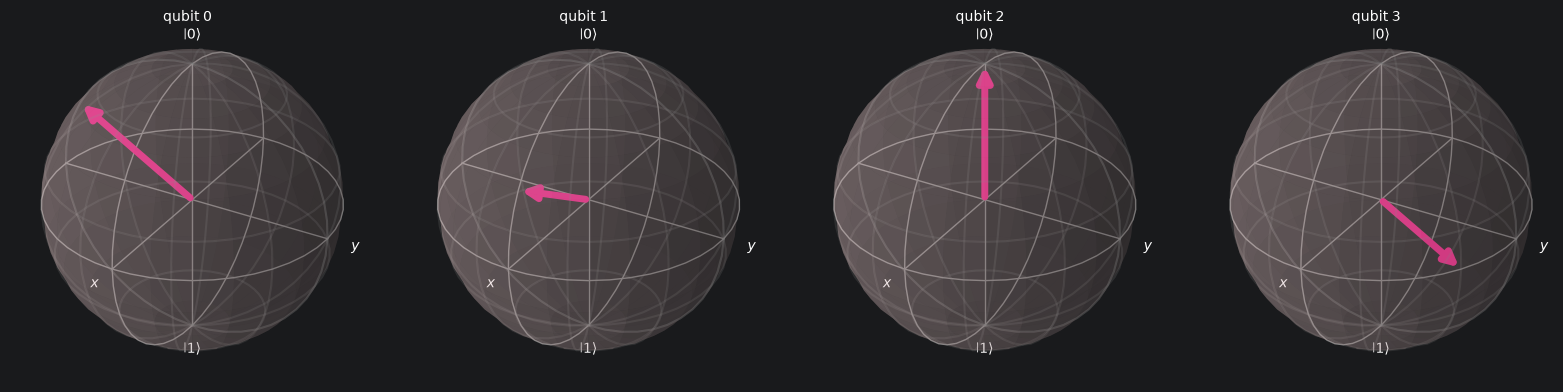

In [23]:
plot_bloch_multivector(statevector)

### Visual Tracking of Parameterized Rotations

* **$R_x$ Gate Impact (First Qubit):** Rotates the state vector $60^\circ$ ($\pi/3$ radians) around the X-axis out of the initial $|0\rangle$ state.
* **$R_y$ Gate Impact (Middle Qubit):** Rotates the state vector $60^\circ$ ($\pi/3$ radians) around the Y-axis out of the initial $|0\rangle$ state.
* **$R_z$ Gate Constraint (Third Qubit):** Applying an $R_z$ rotation to a qubit starting natively on the Z-axis ($|0\rangle$) produces zero observable change, as the state vector sits directly on the axis of rotation.
* **Exposing Phase via Hadamard:** Preceding the $R_z$ gate with an $H$ gate transitions the qubit into a superposition on the X-axis ($|+\rangle$). This configuration makes the subsequent $R_z$ rotation explicitly visible as it shifts the vector away from the X-axis toward the Y-axis.
* **Parameter Conventions:** Input parameters for all rotational operators are passed natively in units of **radians** (using fractions or multiples of $\pi$).
